# Final comparison of model families

This notebook uses the fixed `validate` fold as the **evaluation/tune fold** for model selection. Within each family (CNN, extended CNNs, attention), the variant with the highest tune macro-F1 is selected. The `test` fold is deliberately not loaded until those three winners are frozen. It is then used once for the final, clearly labeled comparison. Looking at test results and subsequently changing the model would turn the test fold into another tuning fold.

Besides accuracy and macro-F1, the comparison includes balanced accuracy, macro precision/recall, Matthews correlation coefficient (MCC), one-vs-rest ROC-AUC, average precision (AP), log loss and multiclass Brier score. AP is useful when class frequencies differ; MCC summarizes the full confusion matrix; log loss and Brier score expose overconfident probability errors.

## 1. Setup and required artifacts

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, classification_report, f1_score, log_loss,
    matthews_corrcoef, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset

from pytorch_timecourse_classification.artifacts import artifact_root, load_model
from pytorch_timecourse_classification.data import Preprocessor, load_prepared_fold

In [2]:
ARTIFACT_PREFIXES = {
    "cnn": "cnn_",
    "extended_cnns": "extended_cnn_",
    "attention": "attention_",
}
artifacts_root = artifact_root()
if not artifacts_root.is_dir():
    raise FileNotFoundError(f"Artifacts directory does not exist: {artifacts_root}")
FAMILY_CANDIDATES = {
    family: tuple(sorted(
        path.name for path in artifacts_root.iterdir()
        if path.is_dir() and path.name.startswith(prefix)
    ))
    for family, prefix in ARTIFACT_PREFIXES.items()
}
empty_families = [family for family, candidates in FAMILY_CANDIDATES.items() if not candidates]
if empty_families:
    raise FileNotFoundError(f"No artifact folders found for: {empty_families}")
artifact_paths = {
    experiment: artifacts_root / experiment / "model.pt"
    for experiments in FAMILY_CANDIDATES.values() for experiment in experiments
}
missing = [str(path) for path in artifact_paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Discovered artifact folders without model.pt: {missing}")
print("Discovered candidates:", FAMILY_CANDIDATES)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

Discovered candidates: {'cnn': ('cnn_baseline', 'cnn_compact', 'cnn_wide'), 'extended_cnns': ('extended_cnn_fft', 'extended_cnn_first_difference', 'extended_cnn_gated_fusion', 'extended_cnn_multi_scale', 'extended_cnn_ordinal', 'extended_cnn_shift_robust', 'extended_cnn_tcn'), 'attention': ('attention_baseline', 'attention_compact')}
device: cuda


## 2. Probability predictions and metrics

In [11]:
def predict_probabilities(model, features, batch_size=256):
    loader = DataLoader(TensorDataset(features), batch_size=batch_size, shuffle=False)
    batches = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            batches.append(model(batch.to(device)).softmax(dim=1).cpu())
    return torch.cat(batches).numpy()


def classification_metrics(targets, probabilities, class_labels):
    predictions = probabilities.argmax(axis=1)
    binary_targets = label_binarize(targets, classes=class_labels)
    return {
        "accuracy": accuracy_score(targets, predictions),
        "balanced_accuracy": balanced_accuracy_score(targets, predictions),
        "macro_precision": precision_score(targets, predictions, average="macro", zero_division=0),
        "macro_recall": recall_score(targets, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(targets, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(targets, predictions, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(targets, predictions),
        "macro_roc_auc_ovr": roc_auc_score(binary_targets, probabilities, average="macro", multi_class="ovr"),
        "macro_average_precision": average_precision_score(binary_targets, probabilities, average="macro"),
        "log_loss": log_loss(targets, probabilities, labels=class_labels),
        "brier_score": np.mean(np.sum((probabilities - binary_targets) ** 2, axis=1)),
    }


def checkpoint_preprocessor(checkpoint):
    return Preprocessor(
        tuple(checkpoint["class_names"]), float(checkpoint["signal_mean"]),
        float(checkpoint["signal_std"]),
    )

## 3. Family-internal selection on eval/tune only

All discovered candidates are evaluated on `validate`. Macro-F1 is the predefined primary selection metric because every dose contributes equally. AP is shown as a probability-ranking diagnostic but does not override the selection rule.

In [12]:
loaded_models = {}
canonical_preprocessor = None
for experiment_name, checkpoint_path in artifact_paths.items():
    model, checkpoint = load_model(checkpoint_path, device=device)
    preprocessor = checkpoint_preprocessor(checkpoint)
    if canonical_preprocessor is None:
        canonical_preprocessor = preprocessor
    elif preprocessor != canonical_preprocessor:
        raise ValueError("Candidate checkpoints use different preprocessing or class order.")
    loaded_models[experiment_name] = model

tune_fold = load_prepared_fold("validate", canonical_preprocessor)
class_names = canonical_preprocessor.class_names
class_labels = np.arange(len(class_names))
tune_probabilities = {
    name: predict_probabilities(model, tune_fold.features)
    for name, model in loaded_models.items()
}
candidate_rows = []
for family, experiments in FAMILY_CANDIDATES.items():
    for experiment in experiments:
        metrics = classification_metrics(
            tune_fold.targets.numpy(), tune_probabilities[experiment], class_labels
        )
        candidate_rows.append({"family": family, "experiment": experiment, **metrics})
candidate_comparison = pd.DataFrame(candidate_rows).set_index(["family", "experiment"])
candidate_comparison.round(4)

accuracy  balanced_accuracy  \
family        experiment                                                   
cnn           cnn_baseline                     0.5673             0.6072   
              cnn_compact                      0.4040             0.3149   
              cnn_wide                         0.7020             0.7267   
extended_cnns extended_cnn_fft                 0.6734             0.7090   
              extended_cnn_first_difference    0.6848             0.7183   
              extended_cnn_gated_fusion        0.6877             0.7234   
              extended_cnn_multi_scale         0.5874             0.6237   
              extended_cnn_ordinal             0.4986             0.5710   
              extended_cnn_shift_robust        0.5587             0.6085   
              extended_cnn_tcn                 0.6791             0.7034   
attention     attention_baseline               0.5931             0.6276   
              attention_compact                0.5931             0.6279   

                                             macro_precision  macro_recall  \
family        experiment                                                     
cnn           cnn_baseline                            0.5692        0.6072   
              cnn_compact                             0.1802        0.3149   
              cnn_wide                                0.7077        0.7267   
extended_cnns extended_cnn_fft                        0.6918        0.7090   
              extended_cnn_first_difference           0.7011        0.7183   
              extended_cnn_gated_fusion               0.7070        0.7234   
              extended_cnn_multi_scale                0.6011        0.6237   
              extended_cnn_ordinal                    0.5263        0.5710   
              extended_cnn_shift_robust               0.5642        0.6085   
              extended_cnn_tcn                        0.6852        0.7034   
attention     attention_baseline                      0.6097        0.6276   
              attention_compact                       0.5982        0.6279   

                                             macro_f1  weighted_f1     mcc  \
family        experiment                                                     
cnn           cnn_baseline                     0.5719       0.5631  0.4844   
              cnn_compact                      0.2099       0.2661  0.2839   
              cnn_wide                         0.7037       0.7013  0.6447   
extended_cnns extended_cnn_fft                 0.6836       0.6741  0.6126   
              extended_cnn_first_difference    0.6933       0.6858  0.6264   
              extended_cnn_gated_fusion        0.6989       0.6880  0.6298   
              extended_cnn_multi_scale         0.6004       0.5880  0.5071   
              extended_cnn_ordinal             0.5009       0.4756  0.4235   
              extended_cnn_shift_robust        0.5661       0.5509  0.4751   
              extended_cnn_tcn                 0.6851       0.6775  0.6145   
attention     attention_baseline               0.5947       0.5789  0.5198   
              attention_compact                0.5954       0.5816  0.5175   

                                             macro_roc_auc_ovr  \
family        experiment                                         
cnn           cnn_baseline                              0.8853   
              cnn_compact                               0.8191   
              cnn_wide                                  0.9443   
extended_cnns extended_cnn_fft                          0.9368   
              extended_cnn_first_difference             0.9412   
              extended_cnn_gated_fusion                 0.9401   
              extended_cnn_multi_scale                  0.9059   
              extended_cnn_ordinal                      0.8795   
              extended_cnn_shift_robust                 0.9053   
              extended_cnn_tcn                          0.9352   
at

In [13]:
family_winners = {
    family: candidate_comparison.loc[family, "macro_f1"].idxmax()
    for family in FAMILY_CANDIDATES
}
print("Frozen family winners selected without test data:")
for family, winner in family_winners.items():
    print(f"  {family}: {winner}")

Frozen family winners selected without test data:
  cnn: cnn_wide
  extended_cnns: extended_cnn_gated_fusion
  attention: attention_compact


## 4. Final tune and test comparison

The three family winners are now frozen. Only from this point onward is `test` loaded. Tune metrics describe model selection; test metrics estimate final generalization.

In [6]:
test_fold = load_prepared_fold("test", canonical_preprocessor)
folds = {"tune (validate)": tune_fold, "test": test_fold}
winner_probabilities = {fold_name: {} for fold_name in folds}
final_rows = []
for fold_name, fold in folds.items():
    for family, experiment in family_winners.items():
        probabilities = (
            tune_probabilities[experiment] if fold_name == "tune (validate)"
            else predict_probabilities(loaded_models[experiment], fold.features)
        )
        winner_probabilities[fold_name][family] = probabilities
        metrics = classification_metrics(fold.targets.numpy(), probabilities, class_labels)
        final_rows.append({"fold": fold_name, "family": family, "experiment": experiment, **metrics})
final_comparison = pd.DataFrame(final_rows).set_index(["fold", "family"])
final_comparison.round(4)

experiment  accuracy  \
fold            family                                               
tune (validate) cnn                             cnn_wide    0.7020   
                extended_cnns  extended_cnn_gated_fusion    0.6877   
                attention              attention_compact    0.5931   
test            cnn                             cnn_wide    0.6991   
                extended_cnns  extended_cnn_gated_fusion    0.6991   
                attention              attention_compact    0.5645   

                               balanced_accuracy  macro_precision  \
fold            family                                              
tune (validate) cnn                       0.7267           0.7077   
                extended_cnns             0.7234           0.7070   
                attention                 0.6279           0.5982   
test            cnn                       0.7256           0.7059   
                extended_cnns             0.7353           0.7166   
                attention                 0.6113           0.5716   

                               macro_recall  macro_f1  weighted_f1     mcc  \
fold            family                                                       
tune (validate) cnn                  0.7267    0.7037       0.7013  0.6447   
                extended_cnns        0.7234    0.6989       0.6880  0.6298   
                attention            0.6279    0.5954       0.5816  0.5175   
test            cnn                  0.7256    0.7018       0.6977  0.6415   
                extended_cnns        0.7353    0.7046       0.6995  0.6466   
                attention            0.6113    0.5654       0.5465  0.4900   

                               macro_roc_auc_ovr  macro_average_precision  \
fold            family                                                      
tune (validate) cnn                       0.9443                   0.7680   
                extended_cnns             0.9401                   0.7531   
                attention                 0.9115                   0.6778   
test            cnn                       0.9454                   0.7660   
                extended_cnns             0.9406                   0.7468   
                attention                 0.9108                   0.6570   

                               log_loss  brier_score  
fold            family                                
tune (validate) cnn              0.6934       0.3978  
                extended_cnns    0.7255       0.4063  
                attention        0.9170       0.5074  
test            cnn              0.6582       0.3778  
                extended_cnns    0.7116       0.4029  
                attention        0.8945       0.5018

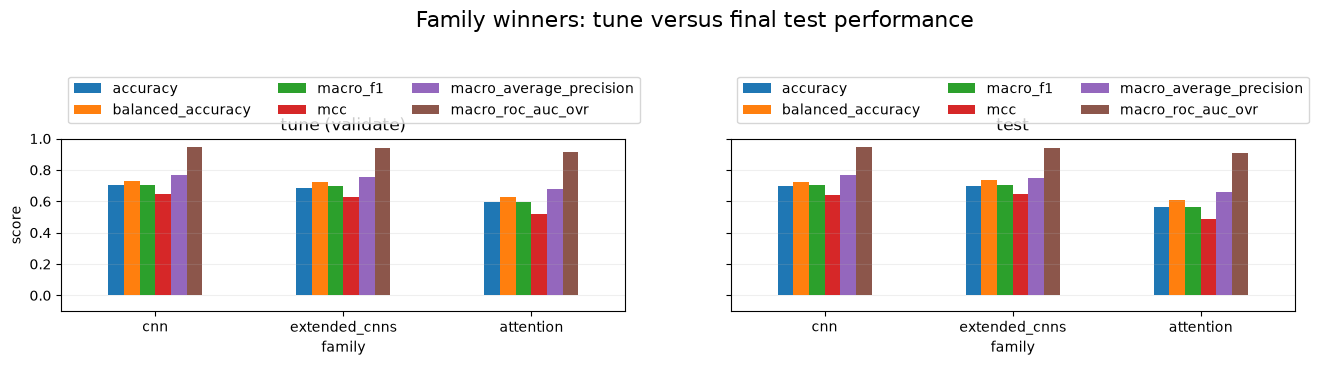

In [53]:
display_metrics = ["accuracy", "balanced_accuracy", "macro_f1", "mcc", "macro_average_precision", "macro_roc_auc_ovr"]
figure, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for axis, fold_name in zip(axes, folds):
    final_comparison.loc[fold_name, display_metrics].plot.bar(ax=axis, ylim=(-0.1, 1), rot=0)
    axis.set(title=fold_name, ylabel="score")
    axis.grid(axis="y", alpha=0.2)
    axis.legend(bbox_to_anchor=(0.0, 1.4), loc="upper left",ncol=3)
figure.suptitle("Family winners: tune versus final test performance", position=(0.5, 0.9), fontsize=16)
figure.tight_layout()

## 5. Final test reports and confusion matrices


TEST — cnn (cnn_wide)
              precision    recall  f1-score   support

         0pM       0.49      0.92      0.63        36
         1pM       0.71      0.56      0.63        78
       2.5pM       0.67      0.59      0.63        66
         5pM       0.69      0.56      0.62        62
        25pM       0.85      0.89      0.87        72
       100pM       0.83      0.83      0.83        35

    accuracy                           0.70       349
   macro avg       0.71      0.73      0.70       349
weighted avg       0.72      0.70      0.70       349


TEST — extended_cnns (extended_cnn_gated_fusion)
              precision    recall  f1-score   support

         0pM       0.47      1.00      0.64        36
         1pM       0.76      0.50      0.60        78
       2.5pM       0.67      0.59      0.63        66
         5pM       0.66      0.65      0.65        62
        25pM       0.91      0.85      0.88        72
       100pM       0.83      0.83      0.83        35

    

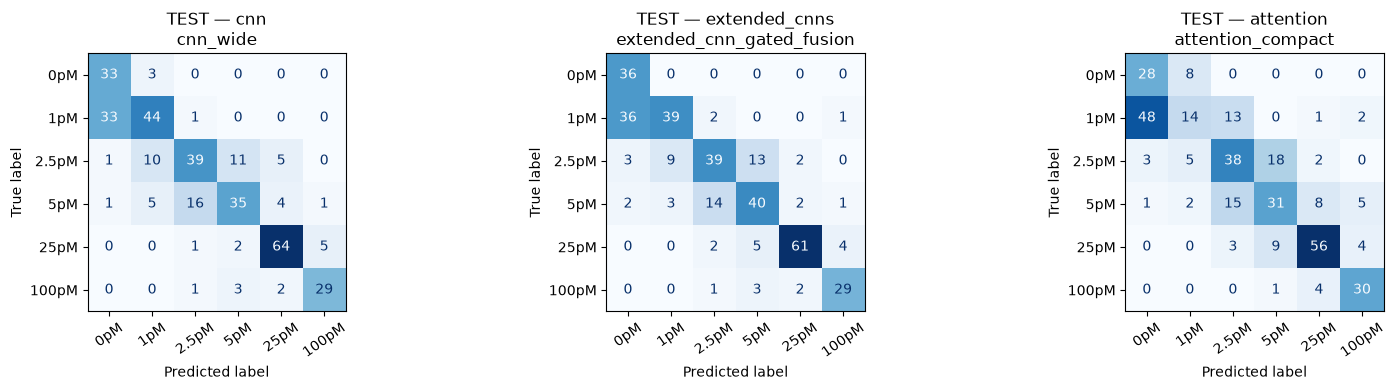

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, (family, experiment) in zip(axes, family_winners.items()):
    predictions = winner_probabilities["test"][family].argmax(axis=1)
    print(f"\nTEST — {family} ({experiment})")
    print(classification_report(
        test_fold.targets.numpy(), predictions, labels=class_labels,
        target_names=class_names, zero_division=0,
    ))
    ConfusionMatrixDisplay.from_predictions(
        test_fold.targets.numpy(), predictions, labels=class_labels,
        display_labels=class_names, xticks_rotation=35, cmap="Blues",
        ax=axis, colorbar=False,
    )
    axis.set_title(f"TEST — {family}\n{experiment}")
figure.tight_layout()

## 6. Test ROC and precision–recall curves

Curves are one-vs-rest for each dose. ROC can look optimistic when negatives dominate; precision–recall curves and AP focus more directly on high-confidence positive predictions.

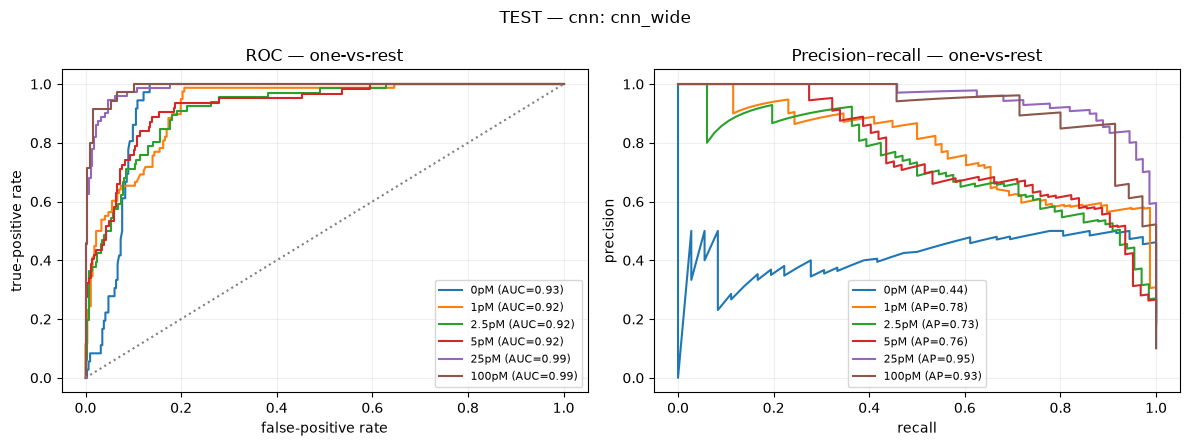

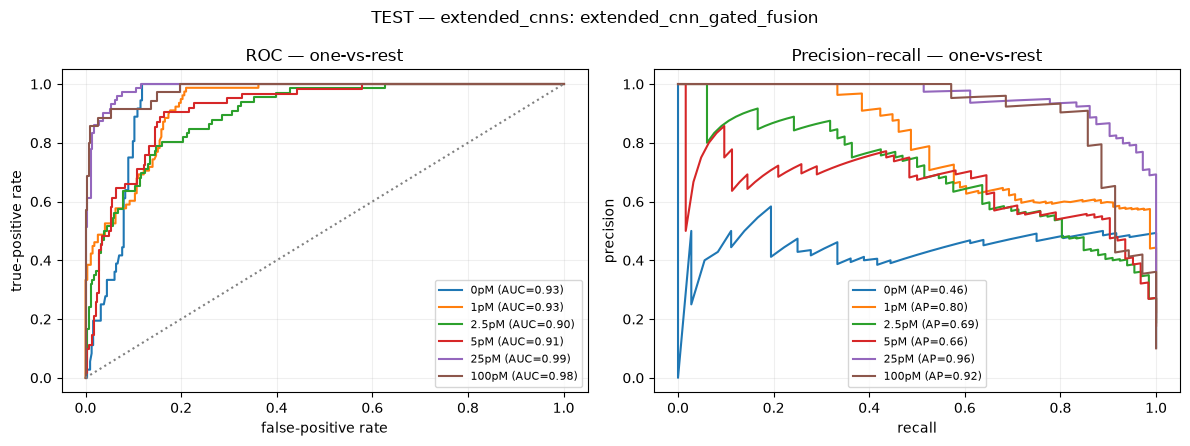

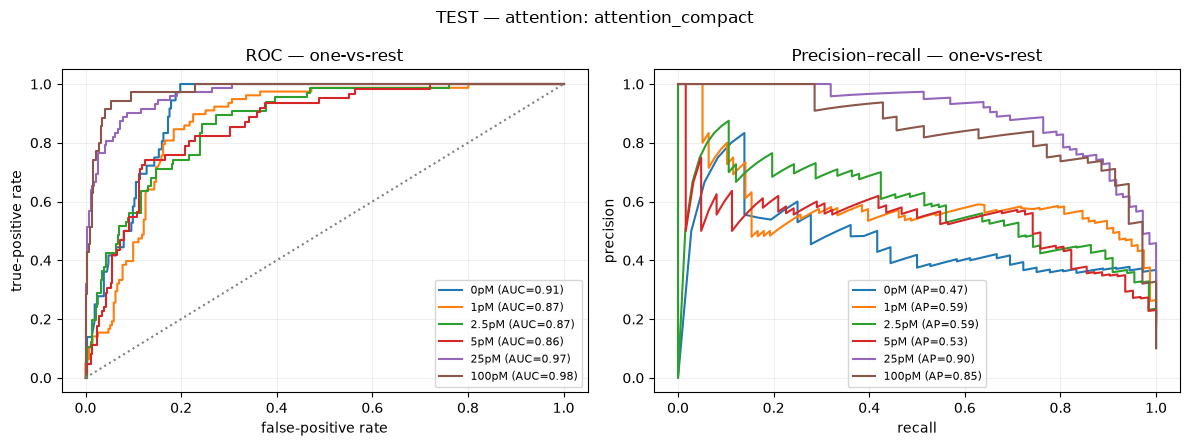

In [9]:
binary_test_targets = label_binarize(test_fold.targets.numpy(), classes=class_labels)
for family, experiment in family_winners.items():
    probabilities = winner_probabilities["test"][family]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for class_index, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(binary_test_targets[:, class_index], probabilities[:, class_index])
        auc = roc_auc_score(binary_test_targets[:, class_index], probabilities[:, class_index])
        precision, recall, _ = precision_recall_curve(binary_test_targets[:, class_index], probabilities[:, class_index])
        ap = average_precision_score(binary_test_targets[:, class_index], probabilities[:, class_index])
        axes[0].plot(fpr, tpr, label=f"{class_name} (AUC={auc:.2f})")
        axes[1].plot(recall, precision, label=f"{class_name} (AP={ap:.2f})")
    axes[0].plot([0, 1], [0, 1], color="0.5", linestyle=":")
    axes[0].set(title="ROC — one-vs-rest", xlabel="false-positive rate", ylabel="true-positive rate")
    axes[1].set(title="Precision–recall — one-vs-rest", xlabel="recall", ylabel="precision")
    for axis in axes:
        axis.legend(fontsize=8)
        axis.grid(alpha=0.2)
    figure.suptitle(f"TEST — {family}: {experiment}")
    figure.tight_layout()

## 7. Interpretation and next steps

In [10]:
gap_metrics = ["accuracy", "balanced_accuracy", "macro_f1", "mcc", "macro_average_precision", "macro_roc_auc_ovr"]
generalization_gaps = (
    final_comparison.loc["test", gap_metrics]
    - final_comparison.loc["tune (validate)", gap_metrics]
)
generalization_gaps.round(4)

,accuracy,balanced_accuracy,macro_f1,mcc,macro_average_precision,macro_roc_auc_ovr
family,,,,,,
cnn,-0.0029,-0.0010,-0.0018,-0.0031,-0.0020,0.0011
extended_cnns,0.0115,0.0120,0.0057,0.0168,-0.0063,0.0005
attention,-0.0287,-0.0165,-0.0300,-0.0275,-0.0208,-0.0007


A small tune–test difference across macro-F1, MCC and AP supports stable generalization. A large test drop suggests selection variance, residual experiment-level leakage, or sensitivity to the fixed split; it should not trigger another round of tuning on test. If accuracy remains high while macro-F1 or AP is weak, inspect class curves and confusion matrices for neglected doses. High ROC-AUC with weaker AP is possible under one-vs-rest imbalance and is not uniformly strong classification.

Next, attach uncertainty with stratified bootstrap confidence intervals and repeat training across seeds while keeping test untouched. Examine probability calibration with reliability diagrams or expected calibration error before using confidence thresholds. If trajectories share biological replicates, repeat the complete protocol with group-aware folds.